In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import joblib
import seaborn as sns

print("All imports successful!")
print(f"XGBoost version: {xgb.__version__}")

All imports successful!
XGBoost version: 3.2.0


In [10]:
np.random.seed(42)
n_samples = 5000

# Generate features
data = {
    'soil_pH':       np.random.uniform(4.0, 9.0, n_samples),
    'nitrogen':      np.random.uniform(0, 140, n_samples),
    'phosphorus':    np.random.uniform(0, 140, n_samples),
    'potassium':     np.random.uniform(0, 140, n_samples),
    'temperature':   np.random.uniform(10, 45, n_samples),
    'humidity':      np.random.uniform(20, 100, n_samples),
    'rainfall':      np.random.uniform(0, 300, n_samples),
}

df = pd.DataFrame(data)

# Assign disease labels based on realistic conditions
def assign_disease(row):
    if row['humidity'] > 80 and row['temperature'] > 25:
        return 'Fungal_Disease'
    elif row['soil_pH'] < 5.5 and row['nitrogen'] < 30:
        return 'Nutrient_Deficiency'
    elif row['temperature'] > 38 and row['rainfall'] < 50:
        return 'Heat_Stress'
    elif row['humidity'] > 70 and row['rainfall'] > 200:
        return 'Bacterial_Disease'
    elif row['potassium'] < 20 and row['phosphorus'] < 20:
        return 'Mineral_Deficiency'
    else:
        return 'Healthy'

df['disease'] = df.apply(assign_disease, axis=1)

# Save
df.to_csv('data/tabular_features.csv', index=False)

print(f"Dataset created: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nDisease distribution:")
print(df['disease'].value_counts())

Dataset created: 5000 rows, 8 columns

Disease distribution:
disease
Healthy                3443
Fungal_Disease          671
Bacterial_Disease       392
Nutrient_Deficiency     285
Heat_Stress             134
Mineral_Deficiency       75
Name: count, dtype: int64


In [11]:
# Load the saved CSV
df = pd.read_csv('data/tabular_features.csv')

# Separate features and labels
X = df.drop('disease', axis=1).values
y = df['disease'].values

# Encode string labels to numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes and their encoded numbers:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i} → {class_name}")

# Split into train/val/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler and label encoder for later use in the API
joblib.dump(scaler, 'models/tabular_scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print(f"\nSplit sizes:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")
print("\nScaler and label encoder saved!")

Classes and their encoded numbers:
  0 → Bacterial_Disease
  1 → Fungal_Disease
  2 → Healthy
  3 → Heat_Stress
  4 → Mineral_Deficiency
  5 → Nutrient_Deficiency

Split sizes:
  Train: (3400, 7)
  Val:   (600, 7)
  Test:  (1000, 7)

Scaler and label encoder saved!


In [12]:
from collections import Counter

# Calculate class weights to handle imbalance
class_counts = Counter(y_train)
total = len(y_train)
class_weights = {cls: total / (len(class_counts) * count) 
                 for cls, count in class_counts.items()}

# Create sample weights array
sample_weights = np.array([class_weights[label] for label in y_train])

print("Class weights (higher = more attention to rare classes):")
for cls, weight in sorted(class_weights.items()):
    print(f"  {label_encoder.classes_[cls]}: {weight:.2f}")

# Train XGBoost
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=1
)

model_xgb.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val_scaled, y_val)],
    verbose=25
)

print("\nTraining complete!")

Class weights (higher = more attention to rare classes):
  Bacterial_Disease: 2.12
  Fungal_Disease: 1.24
  Healthy: 0.24
  Heat_Stress: 6.23
  Mineral_Deficiency: 11.11
  Nutrient_Deficiency: 2.92
[0]	validation_0-mlogloss:1.63338
[25]	validation_0-mlogloss:0.28359
[50]	validation_0-mlogloss:0.07732
[75]	validation_0-mlogloss:0.03257
[100]	validation_0-mlogloss:0.01994
[125]	validation_0-mlogloss:0.01578
[150]	validation_0-mlogloss:0.01352
[175]	validation_0-mlogloss:0.01280
[199]	validation_0-mlogloss:0.01250

Training complete!


In [13]:
# Predict on test set
y_pred = model_xgb.predict(X_test_scaled)

# Overall accuracy
accuracy = (y_pred == y_test).mean() * 100
print(f"Test Accuracy: {accuracy:.2f}%\n")

# Detailed per-class report
print("Per-class breakdown:")
print(classification_report(y_test, y_pred, 
                            target_names=label_encoder.classes_))

Test Accuracy: 99.50%

Per-class breakdown:
                     precision    recall  f1-score   support

  Bacterial_Disease       0.99      1.00      0.99        78
     Fungal_Disease       1.00      1.00      1.00       134
            Healthy       1.00      1.00      1.00       689
        Heat_Stress       1.00      1.00      1.00        27
 Mineral_Deficiency       1.00      0.80      0.89        15
Nutrient_Deficiency       0.98      1.00      0.99        57

           accuracy                           0.99      1000
          macro avg       0.99      0.97      0.98      1000
       weighted avg       1.00      0.99      0.99      1000



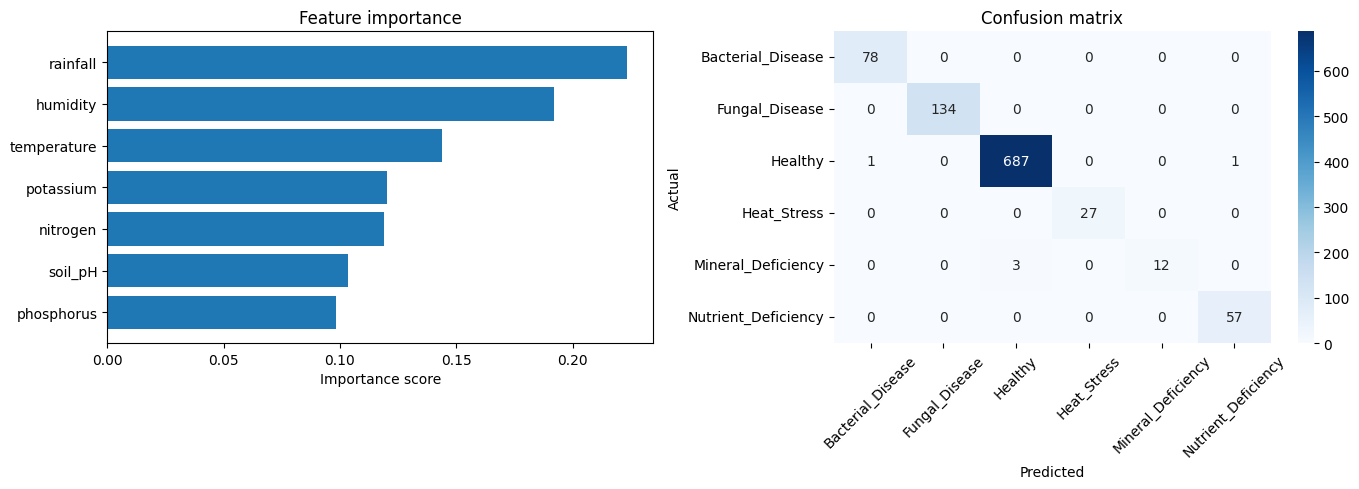

Saved to outputs/tabular_evaluation.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
feature_names = ['soil_pH', 'nitrogen', 'phosphorus', 'potassium', 
                 'temperature', 'humidity', 'rainfall']
importances = model_xgb.feature_importances_
sorted_idx = np.argsort(importances)

ax1.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx])
ax1.set_title('Feature importance')
ax1.set_xlabel('Importance score')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax2)
ax2.set_title('Confusion matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/tabular_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/tabular_evaluation.png")

In [15]:
# Save the XGBoost model
model_xgb.save_model('models/xgboost_tabular.json')

# Save everything needed for inference
tabular_info = {
    'feature_names': ['soil_pH', 'nitrogen', 'phosphorus', 'potassium',
                      'temperature', 'humidity', 'rainfall'],
    'classes': list(label_encoder.classes_),
    'n_classes': len(label_encoder.classes_)
}

with open('data/processed/tabular_info.pkl', 'wb') as f:
    pickle.dump(tabular_info, f)

print("Models saved:")
print("  models/xgboost_tabular.json")
print("  models/tabular_scaler.pkl")
print("  models/label_encoder.pkl")
print("  data/processed/tabular_info.pkl")
print("\nReady for Day 7!")

Models saved:
  models/xgboost_tabular.json
  models/tabular_scaler.pkl
  models/label_encoder.pkl
  data/processed/tabular_info.pkl

Ready for Day 7!
